### Zyxin segmentation and object feature analysis

with Patrick's 2D fixed image two types of Zyxin

Liya Ding, 2025.4

In [11]:
import os
import sys
import tifffile 
import czifile
import numpy as np

In [12]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.FA_object_segmentation import FA_obj_segmenter
from core.FA_obj_feature_extraction import FA_obj_feature_extractor
from utils.display_utils import display_fa_segmentation_panels

In [15]:
image_2D_4CH_dir =  '/mnt/d/lding/FA/data/250406_Complete_Phalloidin405_ZyxinGFP_Zyxin647/rgb_ctrl_seq'

output_dir = '/mnt/d/lding/FA/analysis_results/250406_Complete_Phalloidin405_ZyxinGFP_Zyxin647/ctrl_ch1major'
os.makedirs(output_dir, exist_ok=True)

major_fa_ch = 1
cellmask_ch = 0
supplementary_fa_ch = [2,0]

method_ID = 'code_org_20250416'

csv_output_dir = os.path.join(output_dir, method_ID+'_csv')
plot_output_dir = os.path.join(output_dir, method_ID+'_plot')
seg_output_dir = os.path.join(output_dir, method_ID+'_seg')

pixel_size = 0.17
time_point = 0

os.makedirs(csv_output_dir, exist_ok=True)
os.makedirs(plot_output_dir, exist_ok=True)
os.makedirs(seg_output_dir, exist_ok=True)

sub_dirs = ['mask', 'seg', 'label', 'togglelabel', 'rgb']
for sub_dir in sub_dirs:
    os.makedirs(os.path.join(seg_output_dir, sub_dir), exist_ok=True)


### for each 3D stack run through MIP and 8th frame

In [14]:
# flag for some optinal parts
flag_plot = True
flag_plot_save = True
flag_seg_save = True
flag_csv_save = True
flag_panel_plot = True
flag_run_all  = False

In [5]:
# select the cells that are single/disconnected and complete
ctrl_one_cell_list = [0,1,2,3,4,5,6,7,8,9]

In [ ]:
# for all tif files 
filenames = [x for x in os.listdir(image_2D_4CH_dir) if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and ('.tif' in x)]

# # if not in run all mode, only test with the first image of the first movie
# if not flag_run_all:
#     filenames = filenames[:2]

for filenameID in range(0,len(filenames)):
    
    filename = filenames[filenameID]

    number = int(filename[-7:-4])
    # if number not in ctrl_one_cell_list:
    #     continue

    input_multich_img = np.squeeze(tifffile.imread(os.path.join(image_2D_4CH_dir,filename)))
    input_multich_img = np.transpose(input_multich_img, (2, 0, 1))

    # Initialize the segmenter
    segmenter = FA_obj_segmenter(cellmask_ch = cellmask_ch, major_fa_ch = major_fa_ch, thres_cellmask = 25,                                  
                                    response_threshold = 0.01, major_FA_res_thresholds = [0.5, 0.5, 0.5], min_object_size= 10)

    # Perform segmentation
    [major_FA_seg, new_cell_mask] = segmenter.apply_fa_obj_segmentation(input_multich_img)
   
    # Extract Object features
    extractor = FA_obj_feature_extractor(filename = filename,  pax_seg = major_FA_seg, input_multich_img = input_multich_img,
                                                        new_cell_mask = new_cell_mask, filenameID = filenameID,supplementary_fa_ch=supplementary_fa_ch)

    [fa_obj_features, local_orientation] = extractor.extract_features()
    

    fa_obj_features.to_csv(os.path.join((csv_output_dir), 'fa_obj_features_'+filename+'.csv'))

    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'label'), 'FA_obj_label_'+filename+'.tif'), major_FA_seg.astype(np.uint16))       
    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'mask'), 'cell_mask_'+filename+'.tif'),new_cell_mask.astype(np.uint8))   
    
    # Plot figures for debug and presentation
    pax_image_label_overlay = display_fa_segmentation_panels(input_image = (input_multich_img[major_fa_ch,:,:]), input_cell_mask = new_cell_mask, input_obj_seg = major_FA_seg, local_orientation = local_orientation,
                                   plot_output_dir = plot_output_dir, filename = filename, flag_plot_save = flag_plot_save, flag_run_all = flag_run_all)

    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'rgb'), 'pax_segrgb_'+filename+'.jpg'),pax_image_label_overlay)                     
       

In [8]:
input_multich_img.shape

(1200, 1200, 3)

In [7]:
filename[-7:-4]

'000'

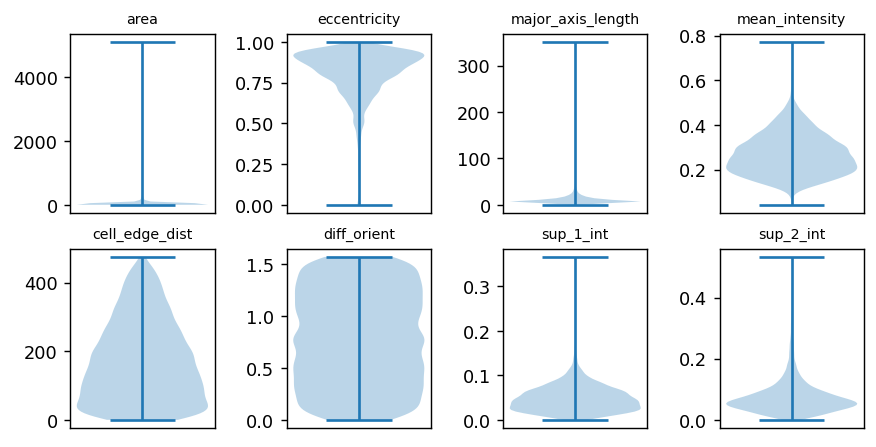

In [7]:
import matplotlib.pyplot as plt 
feature_list = ['area', 'eccentricity', 'major_axis_length','mean_intensity',
                                  'cell_edge_dist','diff_orient','sup_1_int','sup_2_int']

fig, ax = plt.subplots(2, 4, figsize=(8,4), dpi=128, facecolor='w', edgecolor='k')
# plt.subplots_adjust(left=0.3, right=0.7, top=0.8, bottom=0.2)
col_ind = 0
row_ind = 0
import seaborn as sns


for feature in feature_list:
    # sns.violinplot([prop_df_pfak_all[feature][::10].to_numpy().flat],split=True, inner="quart",color='lightblue',ax=ax[row_ind, col_ind])
    V = fa_obj_features[feature].to_numpy().flat
    ax[row_ind, col_ind].violinplot(V)
    ax[row_ind, col_ind].set_title(feature,fontsize=8)
    ax[row_ind, col_ind].set_xticks([],fontsize=8)
    # ax[row_ind, col_ind].set_yticks([np.percentile(V,0.0), int(np.percentile(V,0.0)*2+np.percentile(V,100.0)*1)/3, int(np.percentile(V,0.0)*1+np.percentile(V,100.0)*2)/3,np.percentile(V,100)],fontsize=5)
    # ax[row_ind, col_ind].set_ylim([np.percentile(V,0.0),np.percentile(V,100)])
    ax[row_ind, col_ind].tick_params(axis='both', which='minor', labelsize=8)    
    
    col_ind = col_ind + 1

    if(col_ind==4):
        col_ind = 0
        row_ind = 1
fig.subplots_adjust(wspace=0.5)

In [8]:
fa_obj_features

,filename,cell_ID,time_point,pixel_size,area,bbox_area,convex_area,eccentricity,equivalent_diameter,euler_number,...,min_intensity,minor_axis_length,orientation,perimeter,solidity,cell_edge_dist,cell_edge_orient,diff_orient,sup_1_int,sup_2_int
0,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,3066.0,51219.0,13925.0,0.982910,62.480016,-16.0,...,3.921569e-11,64.611764,-1.085954,1445.858044,0.220180,7.0,0.463648,1.549602,1.744229e-02,2.501596e-02
1,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,1406.0,14964.0,3173.0,0.996047,42.310457,-1.0,...,3.921569e-11,15.738777,-0.842206,498.020382,0.443114,51.0,0.463648,1.305853,6.772700e-02,2.270928e-01
2,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,47.0,88.0,58.0,0.928095,7.735778,1.0,...,3.921569e-03,5.003757,1.105640,29.313708,0.810345,7.0,-0.785398,1.250554,7.421415e-02,1.772683e-01
3,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,11.0,20.0,14.0,0.854906,3.742410,1.0,...,7.843137e-03,2.938829,-1.044971,10.414214,0.785714,7.0,-0.463648,0.581324,2.327910e-02,8.260325e-03
4,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,26.0,42.0,31.0,0.692190,5.753627,1.0,...,3.921569e-11,5.201748,1.474150,19.313708,0.838710,15.0,-1.892547,0.225104,2.139037e-02,3.565062e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7358,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,14.0,25.0,16.0,0.890871,4.222008,1.0,...,1.568627e-02,2.913725,0.643501,10.656854,0.875000,10.0,2.677945,1.107149,1.518671e-02,1.573623e-02
7359,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,1.0,1.0,1.0,0.000000,1.128379,1.0,...,1.568627e-01,0.000000,0.785398,0.000000,1.000000,1.0,3.141593,0.785398,6.162465e-03,1.260504e-02
7360,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,25.0,30.0,25.0,0.657939,5.641896,1.0,...,3.529412e-02,4.864250,-0.435851,15.656854,1.000000,8.0,3.141593,0.435851,3.921569e-11,3.921569e-11
7361,"eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) ...",0.0,0.0,0.07,15.0,35.0,20.0,0.840573,4.370194,1.0,...,3.921569e-11,3.583524,0.365040,12.656854,0.750000,3.0,3.141593,0.365040,8.376471e-02,1.725490e-03
